# Preprocessing — Real-Time Sentiment Analysis (SECP3133 Project 2)

This notebook takes the raw scraped Google Play reviews (`data/raw_data/combined_raw.csv`) and produces a cleaned, labeled dataset (`data/cleaned_data.csv`) ready for model training.

**Steps:**
1. Load raw data and inspect it
2. Map star rating → sentiment label (1-2★ = negative, 3★ = neutral, 4-5★ = positive)
3. Clean the review text (lowercase, remove URLs/mentions/punctuation/numbers)
4. Tokenize, remove stopwords, lemmatize
5. Inspect class balance and flag the known neutral-class imbalance
6. Save the cleaned dataset

**Note on class imbalance:** Star-rating-based sentiment labeling is known to produce very few "neutral" (3-star) examples, since most app reviewers rate at the extremes (1-2 or 4-5 stars). We confirm this below and carry the imbalance forward into `model_training.ipynb`, where we address it with class weighting rather than discarding data.

## 1. Imports and Setup

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download required NLTK data (only needs to run once per machine)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

pd.set_option('display.max_colwidth', 100)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\piyat\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\piyat\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\piyat\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\piyat\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\piyat\AppData\Roaming\nltk_data...


## 2. Load Raw Data

In [3]:
df = pd.read_csv('../scraper/data/raw_data/combined_raw.csv')
print(f"Loaded {len(df)} rows")
df.head()

Loaded 10000 rows


,app_id,app_name,review_id,review_text,score,thumbs_up_count,review_date,reply_content,reply_date,source_sort
0,my.com.tngdigital.ewallet,Touch 'n Go eWallet,8771a48a-2dc7-408b-979f-e6eb5b10c883,Used to be my main ewallet. suddenly they dont allow quick payment and auto top up for debit. Su...,1,8,2026-05-23 17:04:36,"Hello, we appreciate your valuable feedback. Your comments on the matter have been duly acknowle...",2026-05-23 16:59:23,Sort.MOST_RELEVANT
1,my.com.tngdigital.ewallet,Touch 'n Go eWallet,e97a2f8d-9b55-4367-b303-c7ee91f2f75e,"This new version is kinda bad, I tried to use auto debit payment to pay apple+ service but it wa...",2,1,2026-06-13 20:19:42,"Hi there, we sincerely apologize for the inconvenience caused. This issue may be due to network ...",2026-06-13 21:58:04,Sort.MOST_RELEVANT
2,my.com.tngdigital.ewallet,Touch 'n Go eWallet,f5d13046-7db7-4258-8aa8-21f41c93214c,1. stop updating your UI as and when you like when we have been so used to the placement of the ...,1,4,2026-06-06 20:48:34,We sincerely apologize for the frustrations you've encountered with our eWallet. Please know tha...,2026-06-07 21:45:54,Sort.MOST_RELEVANT
3,my.com.tngdigital.ewallet,Touch 'n Go eWallet,69e2f4f5-5912-4d8f-85a9-d64106630a8c,"After many updates, the application has problems when I'm trying logging in, my phone fails to w...",1,15,2026-05-04 18:28:16,We appreciate you for bringing this issue to our attention. We would be glad to assist you with ...,2026-05-05 10:51:24,Sort.MOST_RELEVANT
4,my.com.tngdigital.ewallet,Touch 'n Go eWallet,03ed8978-cafb-4313-8be0-8f2bc7420459,The app works fine until yesterday. It starts to crash every time it's launched so that it becom...,3,16,2026-05-03 12:39:57,"Hi, we're sorry this happened to you. It could be due to network connectivity issue. Please logo...",2026-05-03 21:12:40,Sort.MOST_RELEVANT


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   app_id           10000 non-null  str  
 1   app_name         10000 non-null  str  
 2   review_id        10000 non-null  str  
 3   review_text      10000 non-null  str  
 4   score            10000 non-null  int64
 5   thumbs_up_count  10000 non-null  int64
 6   review_date      10000 non-null  str  
 7   reply_content    8377 non-null   str  
 8   reply_date       8377 non-null   str  
 9   source_sort      10000 non-null  str  
dtypes: int64(2), str(8)
memory usage: 6.1 MB


In [5]:
# Check for missing values
df.isnull().sum()

app_id                0
app_name              0
review_id             0
review_text           0
score                 0
thumbs_up_count       0
review_date           0
reply_content      1623
reply_date         1623
source_sort           0
dtype: int64

## 3. Drop Missing/Empty Reviews

Some reviews may have no text (e.g. a rating with no comment). These rows cannot be used for text-based sentiment classification, so we drop them.

In [6]:
before = len(df)
df = df.dropna(subset=['review_text'])
df = df[df['review_text'].str.strip() != '']
print(f"Dropped {before - len(df)} rows with missing/empty review text")
print(f"Remaining: {len(df)} rows")

Dropped 0 rows with missing/empty review text
Remaining: 10000 rows


## 4. Map Star Rating to Sentiment Label

- 1-2 stars → **negative**
- 3 stars → **neutral**
- 4-5 stars → **positive**

This is a standard weak-labeling approach used widely in review-based sentiment analysis, since manually labeling thousands of reviews is impractical for a 4-week project.

In [7]:
def map_sentiment(score):
    if score <= 2:
        return 'negative'
    elif score == 3:
        return 'neutral'
    else:
        return 'positive'

df['sentiment'] = df['score'].apply(map_sentiment)
df['sentiment'].value_counts()

sentiment
negative    6946
positive    2021
neutral     1033
Name: count, dtype: int64

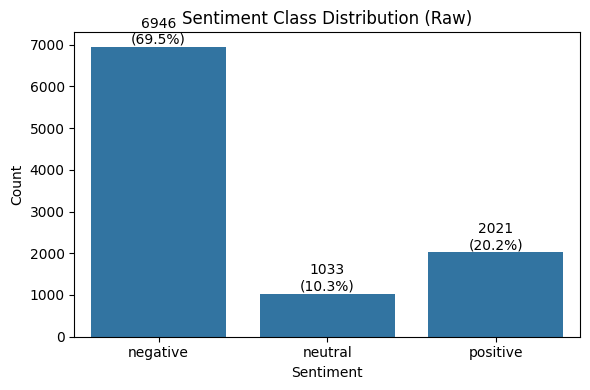

In [8]:
# Visualize class distribution -- this is where the neutral-class imbalance becomes visible
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='sentiment', order=['negative', 'neutral', 'positive'])
plt.title('Sentiment Class Distribution (Raw)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
for i, label in enumerate(['negative', 'neutral', 'positive']):
    count = (df['sentiment'] == label).sum()
    pct = count / len(df) * 100
    plt.text(i, count, f'{count}\n({pct:.1f}%)', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('../reports/sentiment_class_distribution.png', dpi=150)
plt.show()

**Observation:** As expected from star-rating-based labeling, the *neutral* class is heavily underrepresented compared to *negative* and *positive*. This is a structural property of how people rate apps (most reviewers rate at the extremes), not a flaw in our scraping. We will address this explicitly in `model_training.ipynb` using class weighting, and report this as a methodological finding in the report rather than hiding it.

## 5. Text Cleaning Function

Cleaning steps applied to every review:
1. Lowercase the text
2. Remove URLs
3. Remove @mentions
4. Remove punctuation and numbers (keep only letters and spaces)
5. Collapse extra whitespace
6. Tokenize into words
7. Remove English stopwords ("the", "is", "and", etc.)
8. Lemmatize each token (reduce to dictionary base form, e.g. "crashing" → "crash")

In [9]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)   # URLs
    text = re.sub(r'@\w+', ' ', text)                 # mentions
    text = re.sub(r'[^a-z\s]', ' ', text)             # punctuation & numbers
    text = re.sub(r'\s+', ' ', text).strip()          # extra whitespace
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

# Quick test on a few examples
sample_texts = df['review_text'].head(3).tolist()
for t in sample_texts:
    print(f"RAW:     {t}")
    print(f"CLEANED: {clean_text(t)}")
    print()

RAW:     Used to be my main ewallet. suddenly they dont allow quick payment and auto top up for debit. Such a disappointment. It needs a lot of extra steps just to put money inside. Now, it is not as reliable as it used to be. I pull all my money out and only use this for toll and parking only. please bring back auto top up and quick payment for Debit.
CLEANED: used main ewallet suddenly dont allow quick payment auto top debit disappointment need lot extra step put money inside reliable used pull money use toll parking please bring back auto top quick payment debit

RAW:     This new version is kinda bad, I tried to use auto debit payment to pay apple+ service but it was still pending even though I already top up some money to my ewallet. It's been pending for a few days I don't know how to settle those payments, I linked to my ipad and unlinked a lot of times and it still can't pay the pending payment, I wish I can pay it manually so that it won't stay pending in my account. If the pe

In [10]:
# Apply cleaning to the whole dataset (this may take a minute or two for 10k rows)
df['cleaned_text'] = df['review_text'].apply(clean_text)
df[['review_text', 'cleaned_text', 'sentiment']].head(10)

,review_text,cleaned_text,sentiment
0,Used to be my main ewallet. suddenly they dont allow quick payment and auto top up for debit. Su...,used main ewallet suddenly dont allow quick payment auto top debit disappointment need lot extra...,negative
1,"This new version is kinda bad, I tried to use auto debit payment to pay apple+ service but it wa...",new version kinda bad tried use auto debit payment pay apple service still pending even though a...,negative
2,1. stop updating your UI as and when you like when we have been so used to the placement of the ...,stop updating ui like used placement item everyday transaction even move keep name consistent su...,negative
3,"After many updates, the application has problems when I'm trying logging in, my phone fails to w...",many update application problem trying logging phone fails work due system crash really disturbi...,negative
4,The app works fine until yesterday. It starts to crash every time it's launched so that it becom...,app work fine yesterday start crash every time launched becomes completely unusable even reinsta...,neutral
5,"idk what's wrong with this e wallet. when i try to open the app, my phone crashes and i have to ...",idk wrong wallet try open app phone crash wait almost minute ton notification said system ui res...,negative
6,"It barely works on the Redmi a5, first time I tried it, I crashed 2 times. I had to wait for min...",barely work redmi first time tried crashed time wait minute load without error sometimes app loa...,neutral
7,Been lagging and slowing down upon app startup lately in these 2 months. Took up to 30 seconds j...,lagging slowing upon app startup lately month took second open app without biometric authenticat...,negative
8,last week maybe on Saturday my tng app suddenly crashed after I opened it. even if it did not cr...,last week maybe saturday tng app suddenly crashed opened even crash took like min open app compl...,neutral
9,"Nowadays, the app keeps crashing and run slower plus sluggish even after forcing it to stop or c...",nowadays app keep crashing run slower plus sluggish even forcing stop clear cache reason run per...,negative


## 6. Drop Rows That Became Empty After Cleaning

Some reviews consist only of stopwords, emojis, or symbols (e.g. "!!!" or ":)"). After cleaning, these become empty strings and must be removed since they carry no usable text signal.

In [11]:
before = len(df)
df = df[df['cleaned_text'].str.strip() != '']
print(f"Dropped {before - len(df)} rows that became empty after cleaning")
print(f"Final dataset size: {len(df)} rows")

Dropped 0 rows that became empty after cleaning
Final dataset size: 10000 rows


## 7. Check for Duplicate Reviews

Duplicate reviews (e.g. copy-pasted spam, or the scraper accidentally collecting the same review twice) can bias the model. We remove exact duplicates on the cleaned text.

In [12]:
before = len(df)
df = df.drop_duplicates(subset=['cleaned_text'])
print(f"Dropped {before - len(df)} duplicate reviews")
print(f"Final dataset size: {len(df)} rows")

Dropped 21 duplicate reviews
Final dataset size: 9979 rows


## 8. Final Class Distribution Check

In [13]:
final_counts = df['sentiment'].value_counts()
final_pct = (final_counts / len(df) * 100).round(1)
summary = pd.DataFrame({'count': final_counts, 'percentage': final_pct})
print(summary)

           count  percentage
sentiment                   
negative    6944        69.6
positive    2002        20.1
neutral     1033        10.4


## 9. Save Cleaned Dataset

In [14]:
output_cols = ['app_id', 'app_name', 'review_id', 'review_text', 'cleaned_text',
               'score', 'sentiment', 'thumbs_up_count', 'review_date']
df_final = df[output_cols]

df_final.to_csv('../data/cleaned_data.csv', index=False)
print(f"Saved {len(df_final)} rows to ../data/cleaned_data.csv")
df_final.head()

Saved 9979 rows to ../data/cleaned_data.csv


,app_id,app_name,review_id,review_text,cleaned_text,score,sentiment,thumbs_up_count,review_date
0,my.com.tngdigital.ewallet,Touch 'n Go eWallet,8771a48a-2dc7-408b-979f-e6eb5b10c883,Used to be my main ewallet. suddenly they dont allow quick payment and auto top up for debit. Su...,used main ewallet suddenly dont allow quick payment auto top debit disappointment need lot extra...,1,negative,8,2026-05-23 17:04:36
1,my.com.tngdigital.ewallet,Touch 'n Go eWallet,e97a2f8d-9b55-4367-b303-c7ee91f2f75e,"This new version is kinda bad, I tried to use auto debit payment to pay apple+ service but it wa...",new version kinda bad tried use auto debit payment pay apple service still pending even though a...,2,negative,1,2026-06-13 20:19:42
2,my.com.tngdigital.ewallet,Touch 'n Go eWallet,f5d13046-7db7-4258-8aa8-21f41c93214c,1. stop updating your UI as and when you like when we have been so used to the placement of the ...,stop updating ui like used placement item everyday transaction even move keep name consistent su...,1,negative,4,2026-06-06 20:48:34
3,my.com.tngdigital.ewallet,Touch 'n Go eWallet,69e2f4f5-5912-4d8f-85a9-d64106630a8c,"After many updates, the application has problems when I'm trying logging in, my phone fails to w...",many update application problem trying logging phone fails work due system crash really disturbi...,1,negative,15,2026-05-04 18:28:16
4,my.com.tngdigital.ewallet,Touch 'n Go eWallet,03ed8978-cafb-4313-8be0-8f2bc7420459,The app works fine until yesterday. It starts to crash every time it's launched so that it becom...,app work fine yesterday start crash every time launched becomes completely unusable even reinsta...,3,neutral,16,2026-05-03 12:39:57


## Next Step

Proceed to `model_training.ipynb` to train and compare the Naive Bayes and LSTM sentiment classifiers on `cleaned_data.csv`.